# Visualização de Dados: Natureza Jurídica x Capital Social no Brasil

## 1. Configuração Inicial e Importação de Bibliotecas
Nesta primeira etapa, importamos as bibliotecas fundamentais para a análise de dados (`pandas`) e para a construção das visualizações (`matplotlib` e `seaborn`). Também configuramos um padrão visual global para garantir que os gráficos gerados tenham qualidade de publicação, com fontes legíveis e cores acessíveis, cumprindo os critérios de avaliação visual do laboratório.

In [1]:
# PASSO 1: Importação de bibliotecas e configuração visual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
import os

# Configurando o estilo visual dos gráficos (Requisito: Qualidade visual do lab)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

print("Bibliotecas importadas e ambiente configurado com sucesso!")

Bibliotecas importadas e ambiente configurado com sucesso!


## 2. Integração com o Google Drive
Para lidar com o grande volume de dados abertos da Receita Federal (que chegam a dezenas de gigabytes), vamos utilizar o Google Drive como nosso repositório de armazenamento. Isso evita a necessidade de realizar o download do banco de dados completo a cada nova execução do ambiente de desenvolvimento, poupando tempo e recursos de rede.

In [2]:
from google.colab import drive
import os

# Isso vai conectar o sistema de arquivos do Colab ao seu Google Drive pessoal
drive.mount('/content/drive')

# Criar uma pasta específica no seu Drive para organizar os dados do laboratório
pasta_destino_drive = "/content/drive/MyDrive/cgvis_lab3_dados"
os.makedirs(pasta_destino_drive, exist_ok=True)

print(f"Google Drive conectado! A pasta '{pasta_destino_drive}' está pronta para uso.")

Mounted at /content/drive
Google Drive conectado! A pasta '/content/drive/MyDrive/cgvis_lab3_dados' está pronta para uso.


## 3. Aquisição e Extração dos Dados Brutos
Os dados utilizados são referentes ao Cadastro Nacional da Pessoa Jurídica (CNPJ) fornecidos abertamente pela Receita Federal. O código a seguir automatiza o download de uma amostra dos dados (arquivo `Empresas0.zip`) diretamente do servidor do governo e realiza a extração do arquivo CSV principal para a nossa pasta no Google Drive.

*(Nota: Este passo só precisa ser executado uma vez para popular o Drive).*

In [ ]:
# PASSO 2: Download e Extração dos Dados
import requests
import zipfile
import os
import time

# Substitua o texto abaixo pelo link copiado do botão "Acessar o recurso"
url_zip = "https://arquivos.receitafederal.gov.br/public.php/dav/files/YggdBLfdninEJX9/2026-05/Empresas0.zip"

print("Iniciando o download do arquivo ZIP... Isso pode demorar alguns minutos.")
resposta = requests.get(url_zip, stream=True)

inicio_download = time.time()
ultimo_aviso = inicio_download

with open("dados_cnpj.zip", "wb") as arquivo:
    for chunk in resposta.iter_content(chunk_size=8192):
        arquivo.write(chunk)
        tempo_atual = time.time()
        if tempo_atual - ultimo_aviso >= 60:
            minutos_passados = int((tempo_atual - inicio_download) // 60)
            print(f"Tempo em andamento: {minutos_passados} minuto(s) decorrido(s)...")
            ultimo_aviso = tempo_atual

tempo_total = time.time() - inicio_download
minutos_totais = int(tempo_total // 60)
segundos_totais = int(tempo_total % 60)
print(f"Tempo total de download: {minutos_totais} minuto(s) e {segundos_totais} segundo(s).")

print("Download concluído! Extraindo os arquivos...")
with zipfile.ZipFile("dados_cnpj.zip", 'r') as zip_ref:
    zip_ref.extractall("dados_extraidos")
    arquivos_extraidos = zip_ref.namelist()

print(f"\nSucesso! Os seguintes arquivos foram extraídos e estão prontos para uso:")
for nome_arquivo in arquivos_extraidos:
    print(f"- {nome_arquivo}")

Iniciando o download do arquivo ZIP... Isso pode demorar alguns minutos.
Tempo em andamento: 1 minuto(s) decorrido(s)...
Tempo em andamento: 2 minuto(s) decorrido(s)...
Tempo em andamento: 3 minuto(s) decorrido(s)...
Tempo em andamento: 4 minuto(s) decorrido(s)...
Tempo em andamento: 5 minuto(s) decorrido(s)...
Tempo em andamento: 6 minuto(s) decorrido(s)...
Tempo em andamento: 7 minuto(s) decorrido(s)...
Tempo em andamento: 8 minuto(s) decorrido(s)...
Tempo em andamento: 9 minuto(s) decorrido(s)...
Tempo total de download: 9 minuto(s) e 41 segundo(s).
Download concluído! Extraindo os arquivos...

Sucesso! Os seguintes arquivos foram extraídos e estão prontos para uso:
- K3241.K03200Y0.D60509.EMPRECSV


In [ ]:
import zipfile

caminho_zip_local = "dados_cnpj.zip"
pasta_destino_drive = "/content/drive/MyDrive/cgvis_lab3_dados"

print("Extraindo o arquivo ZIP diretamente para o seu Google Drive...")
print("Isso pode levar um tempinho porque o arquivo é grande e está sendo gravado na nuvem.")

with zipfile.ZipFile(caminho_zip_local, 'r') as zip_ref:
    zip_ref.extractall(pasta_destino_drive)

print(f"\nSucesso total! Verifique o seu Google Drive, os arquivos foram salvos em: {pasta_destino_drive}")
print(f"Arquivos na pasta do Drive: {os.listdir(pasta_destino_drive)}")

Extraindo o arquivo ZIP diretamente para o seu Google Drive...
Isso pode levar um tempinho porque o arquivo é grande e está sendo gravado na nuvem.

Sucesso total! Verifique o seu Google Drive, os arquivos foram salvos em: /content/drive/MyDrive/cgvis_lab3_dados
Arquivos na pasta do Drive: ['K3241.K03200Y0.D60509.EMPRECSV']


## 4. Carregamento Otimizado e Limpeza Inicial
O arquivo CSV bruto extraído não possui cabeçalhos. Utilizando o **Dicionário de Dados do CNPJ**, mapeamos os nomes das colunas. Para não sobrecarregar a memória RAM do Google Colab com um arquivo tão extenso, utilizamos o parâmetro `usecols` do `pandas` para carregar exclusivamente as colunas que importam para a nossa visualização (CNPJ, Natureza Jurídica, Capital Social e Porte). Em seguida, convertemos os valores de "Capital Social" de texto para números decimais (float).

In [3]:
import pandas as pd

# Agora o caminho aponta diretamente para a pasta do seu Google Drive!
caminho_csv_drive = "/content/drive/MyDrive/cgvis_lab3_dados/K3241.K03200Y0.D60509.EMPRECSV"

colunas_empresas = [
    "cnpj_basico", "razao_social", "natureza_juridica",
    "qualificacao_responsavel", "capital_social", "porte_empresa", "ente_federativo"
]
colunas_interesse = ["cnpj_basico", "natureza_juridica", "capital_social", "porte_empresa"]

print("Lendo o arquivo CSV diretamente do seu Google Drive... Aguarde uns instantes.")

df_empresas = pd.read_csv(
    caminho_csv_drive,
    sep=';',
    header=None,
    names=colunas_empresas,
    usecols=colunas_interesse,
    dtype={'cnpj_basico': str, 'natureza_juridica': str, 'porte_empresa': str},
    encoding='latin1'
)

df_empresas['capital_social'] = df_empresas['capital_social'].str.replace(',', '.').astype(float)

print(f"Sucesso! Dataset carregado direto do Drive com {df_empresas.shape[0]} empresas.")
display(df_empresas.head())

Lendo o arquivo CSV diretamente do seu Google Drive... Aguarde uns instantes.
Sucesso! Dataset carregado direto do Drive com 27628041 empresas.


,cnpj_basico,natureza_juridica,capital_social,porte_empresa
0,41273590,4014,0.0,05
1,41273591,2135,1000.0,01
2,41273592,2135,30000.0,01
3,41273593,2135,3000.0,01
4,41273594,2135,5000.0,01


## 5. Preparação dos Dados, Amostragem e Visualização Final

Nesta etapa, focamos em responder à nossa pergunta de pesquisa: **Qual é a disparidade de volume e de poder econômico (Capital Social) entre os principais tipos de empresas no Brasil?**

Para isso, traduzimos os códigos de Natureza Jurídica com base no Dicionário de Dados da RFB. Como o dataset original possui mais de 27 milhões de registros, extraímos uma **amostra representativa e aleatória de 100 mil empresas** e a exportamos para um arquivo `.csv` leve. Este processo garante a reprodutibilidade deste notebook por terceiros sem a necessidade de processar dezenas de gigabytes.

Por fim, geramos dois gráficos lado a lado: um focando no volume de registros e outro na distribuição do capital social (em escala logarítmica para lidar com a assimetria característica de dados financeiros).

Filtrando e traduzindo os dados...
Gerando amostra de 100 mil registros para reprodutibilidade...
Gerando visualização aprimorada...


/tmp/ipykernel_698/182436910.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_698/182436910.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(



Concluído! A nova imagem foi salva como 'imagem-da-visualizacao.png'.


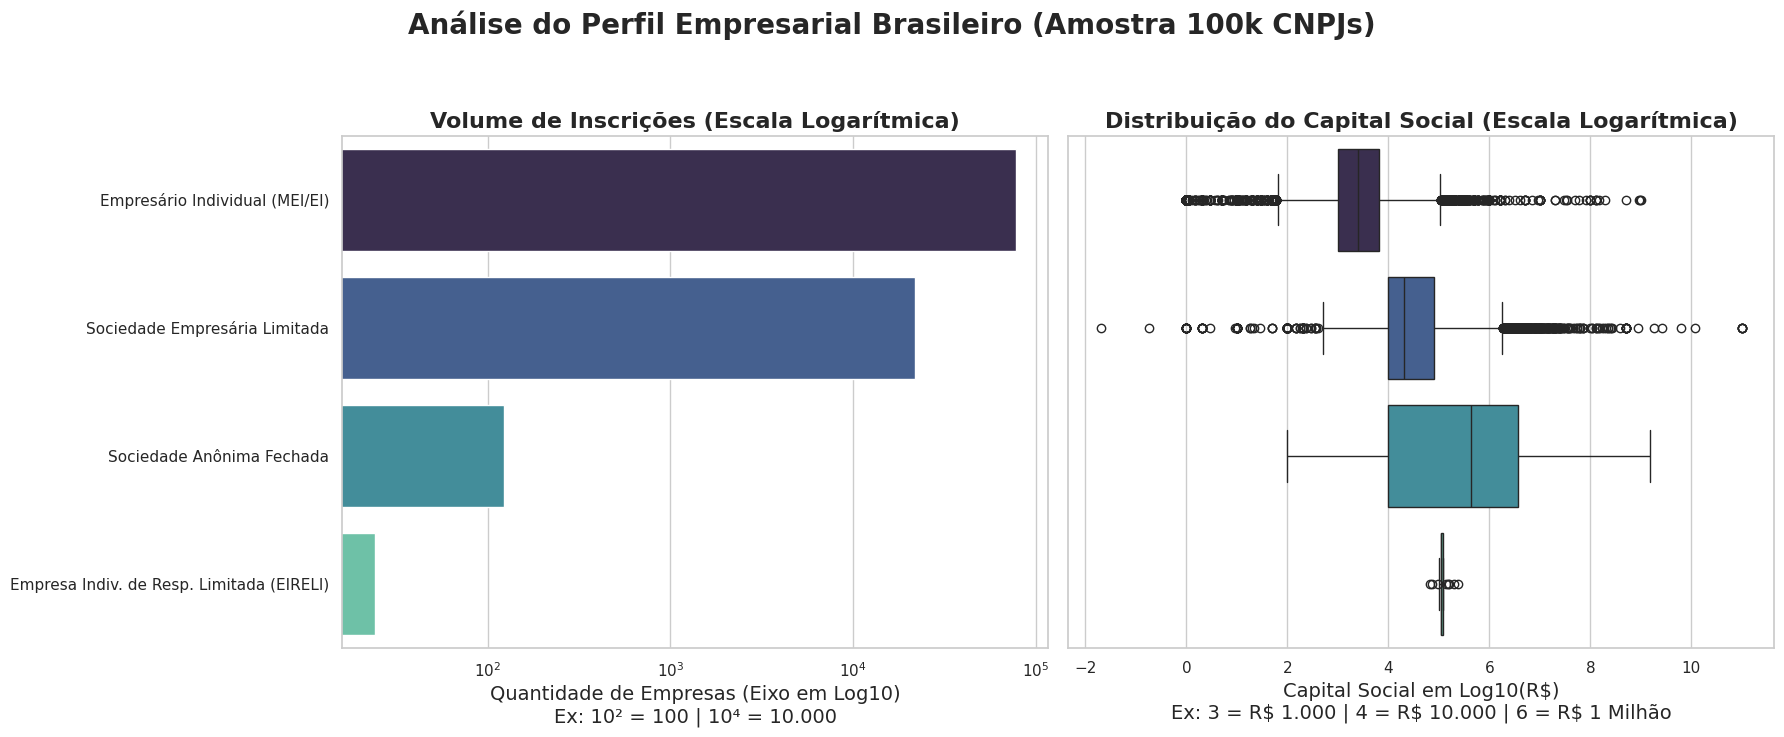

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dicionário de tradução das Naturezas Jurídicas mais comuns
dic_natureza = {
    '2135': 'Empresário Individual (MEI/EI)',
    '2062': 'Sociedade Empresária Limitada',
    '3999': 'Associação Privada',
    '2054': 'Sociedade Anônima Fechada',
    '2305': 'Empresa Indiv. de Resp. Limitada (EIRELI)'
}

# 2. Filtrar o dataset gigante apenas para essas naturezas e remover capitais zerados/inválidos
print("Filtrando e traduzindo os dados...")
df_top = df_empresas[df_empresas['natureza_juridica'].isin(dic_natureza.keys())].copy()
df_top['nome_natureza'] = df_top['natureza_juridica'].map(dic_natureza)
df_top = df_top[df_top['capital_social'] > 0]

# 3. Gerar a Amostra para o Professor (100.000 linhas)
print("Gerando amostra de 100 mil registros para reprodutibilidade...")
df_amostra = df_top.sample(n=100000, random_state=42)

# Salva localmente e no Drive
df_amostra.to_csv("amostra_cnpj_para_professor.csv", index=False)
df_amostra.to_csv("/content/drive/MyDrive/cgvis_lab3_dados/amostra_cnpj_para_professor.csv", index=False)

# Aplica log10 no capital social
df_amostra['log_capital'] = np.log10(df_amostra['capital_social'])

# 4. Criando as Visualizações
print("Gerando visualização aprimorada...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Análise do Perfil Empresarial Brasileiro (Amostra 100k CNPJs)', fontsize=20, weight='bold', y=1.05)

ordem_volume = df_amostra['nome_natureza'].value_counts().index

# Gráfico 1: Volume de Empresas (Barplot com Escala Logarítmica)
sns.countplot(
    data=df_amostra,
    y='nome_natureza',
    order=ordem_volume,
    palette='mako',
    ax=axes[0]
)
axes[0].set_xscale('log') # <-- O TRUQUE PARA FAZER APARECER AS S.A. E EIRELIs
axes[0].set_title('Volume de Inscrições (Escala Logarítmica)', weight='bold')
axes[0].set_xlabel('Quantidade de Empresas (Eixo em Log10)\nEx: 10² = 100 | 10⁴ = 10.000')
axes[0].set_ylabel('')

# Gráfico 2: Distribuição de Capital Social (Boxplot)
sns.boxplot(
    data=df_amostra,
    y='nome_natureza',
    x='log_capital',
    order=ordem_volume,
    palette='mako',
    ax=axes[1]
)
axes[1].set_title('Distribuição do Capital Social (Escala Logarítmica)', weight='bold')
axes[1].set_xlabel('Capital Social em Log10(R$)\nEx: 3 = R$ 1.000 | 4 = R$ 10.000 | 6 = R$ 1 Milhão')
axes[1].set_ylabel('')
axes[1].set_yticks([])

plt.tight_layout()

# Salvar a imagem corrigida
plt.savefig("imagem-da-visualizacao.png", dpi=300, bbox_inches='tight')
print("\nConcluído! A nova imagem foi salva como 'imagem-da-visualizacao.png'.")
plt.show()